<a href="https://colab.research.google.com/github/JasaSK/KlasifikasiKesehatanCitraDaunTomatMetodeKNN/blob/main/2318063JasaKlasifikasiKesehatanCitraDaunTomatMetodeKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library & Mount Google Drive**
mengimpor semua library yang dibutuhkan serta menghubungkan Google Drive ke Colab agar dataset bisa diakses.

In [137]:
import cv2
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Menentukan Path Dataset**
Menentukan lokasi dataset gambar daun yang ada di Google Drive.

In [138]:
dataset_path = "/content/drive/MyDrive/dataset_daun"

# **3. Fungsi Ekstraksi Fitur**
digunakan untuk mengambil fitur dari citra:
*   Warna → mean RGB
*   Bentuk → area & perimeter
*   Tekstur → GLCM (contrast, energy, homogeneity)









In [139]:
def extract_features(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Gambar tidak terbaca: {image_path}")

    img = cv2.resize(img, (200, 200))

    # 1. FITUR WARNA
    mean_color = img.mean(axis=(0,1))  # BGR

    # 2. PREPROCESSING
    blur = cv2.GaussianBlur(img, (5,5), 0)
    gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)

    # threshold OTSU
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # morphology (bersihkan noise)
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # 3. FITUR BENTUK
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
    else:
        area = 0
        perimeter = 0

    # 4. FITUR TEKSTUR (GLCM)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    return [
        mean_color[0], mean_color[1], mean_color[2],
        area, perimeter,
        contrast, energy, homogeneity
    ]

# **4. Visualisasi Preprocessing**
Menampilkan gambar sebelum dan sesudah preprocessing.

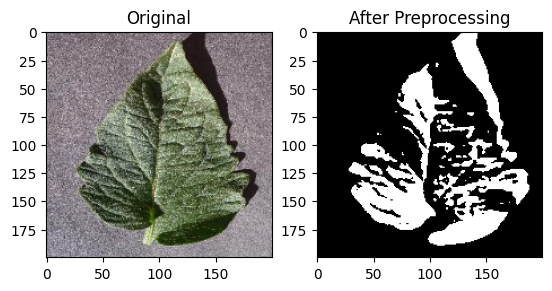

In [140]:
# Ambil 1 sample gambar
sample_img_path = os.path.join(dataset_path, os.listdir(dataset_path)[0])

img = cv2.imread(sample_img_path)
img = cv2.resize(img, (200, 200))

blur = cv2.GaussianBlur(img, (5,5), 0)
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("After Preprocessing")
plt.imshow(thresh, cmap='gray')
plt.show()

# **5. Ekstraksi Dataset**
Loop semua gambar → ambil fitur → beri label.

In [141]:
features = []
labels = []

for file in os.listdir(dataset_path):

    if file.lower().endswith(('.jpg', '.jpeg', '.png')):

        img_path = os.path.join(dataset_path, file)

        # label dari nama file
        if "RS_HL" in file:
            label = "RS_HL"
        elif "GH_HL" in file:
            label = "GH_HL"
        else:
            continue

        try:
            feat = extract_features(img_path)
            features.append(feat)
            labels.append(label)
        except:
            print("Error:", file)

print("Jumlah data:", len(features))

Jumlah data: 628


# **6. Membuat DataFrame**
Mengubah fitur menjadi tabel dataset.

In [142]:
columns = [
    "mean_B", "mean_G", "mean_R",
    "area", "perimeter",
    "contrast", "energy", "homogeneity"
]

df = pd.DataFrame(features, columns=columns)
df["label"] = labels

df.to_csv("/content/fitur_daun.csv", index=False)

df.head()

,mean_B,mean_G,mean_R,area,perimeter,contrast,energy,homogeneity,label
0,109.969900,118.626175,118.830625,2324.0,430.132030,61.211055,0.027079,0.227554,RS_HL
1,104.120500,112.611200,115.238850,5755.5,1039.192993,57.593191,0.026707,0.235812,RS_HL
2,109.653175,117.848650,118.126450,4509.0,925.210238,59.262789,0.026495,0.237620,RS_HL
3,108.360050,127.782450,114.879175,10301.0,1241.352374,10.445302,0.045877,0.400184,GH_HL
4,119.802575,127.555150,120.987700,1649.0,400.877197,38.823241,0.030778,0.272823,RS_HL


# **7. Split Data & Training KNN**
Membagi data train-test dan melatih model KNN.

In [143]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# **8. Evaluasi Model**
Melihat performa model menggunakan:
*   Akurasi
*   Confusion matrix
*   Confusion matrix

In [144]:
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Akurasi: 0.9444444444444444

Classification Report:
               precision    recall  f1-score   support

       GH_HL       0.93      0.91      0.92        45
       RS_HL       0.95      0.96      0.96        81

    accuracy                           0.94       126
   macro avg       0.94      0.94      0.94       126
weighted avg       0.94      0.94      0.94       126


Confusion Matrix:
 [[41  4]
 [ 3 78]]


# **9. Prediksi Gambar Baru**
Menguji model dengan gambar baru.

Prediksi: GH_HL


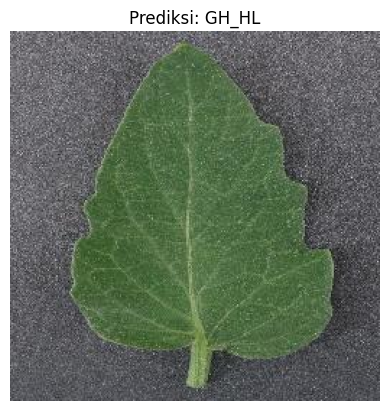

In [145]:
test_img = "/content/drive/MyDrive/dataset_daun/sample.JPG"

feat = extract_features(test_img)
feat_df = pd.DataFrame([feat], columns=columns)

pred = model.predict(feat_df)
print("Prediksi:", pred[0])

img = cv2.imread(test_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Prediksi: {pred[0]}")
plt.axis("off")
plt.show()

# **10. Visualisasi Distribusi Data**
Menampilkan jumlah data tiap kelas.

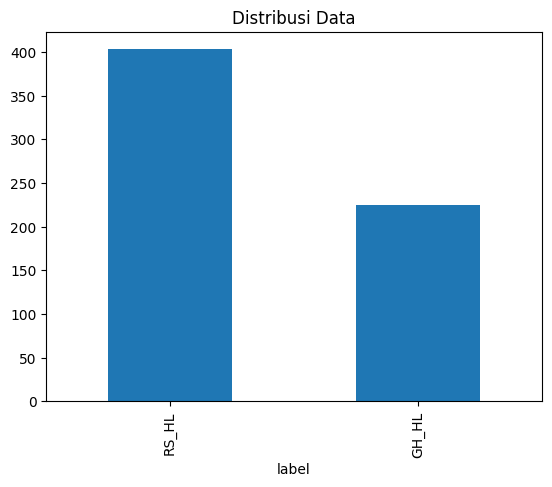

In [146]:
df["label"].value_counts().plot(kind='bar')
plt.title("Distribusi Data")
plt.show()

# **11. Visualisasi Fitur**
Melihat distribusi fitur menggunakan boxplot & histogram.

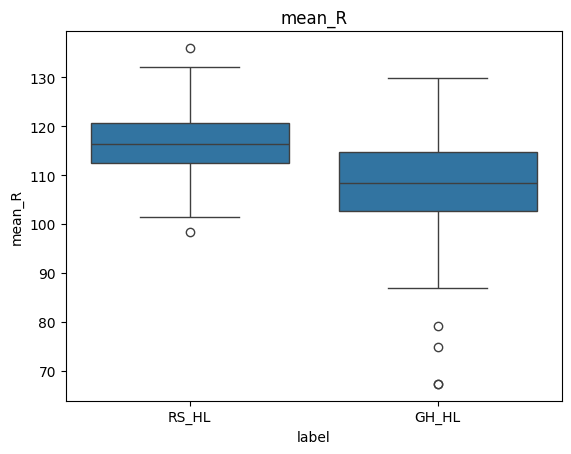

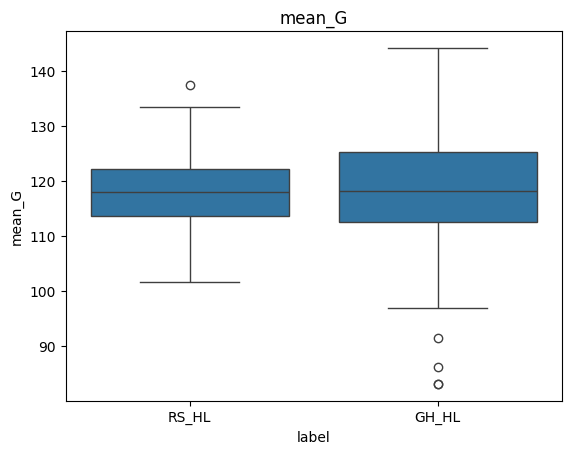

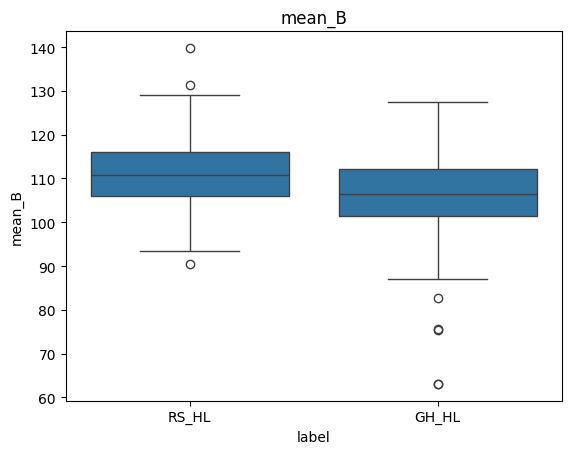

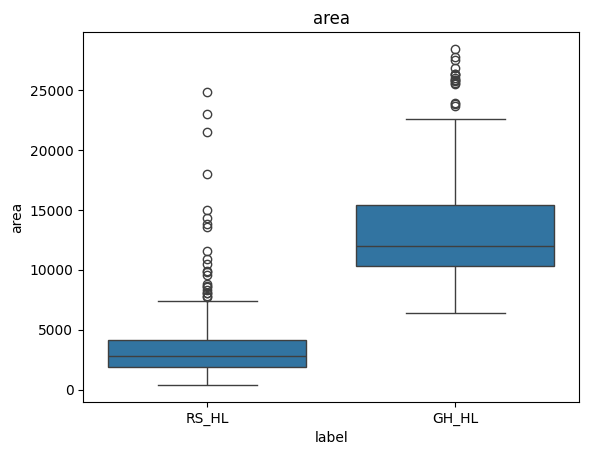

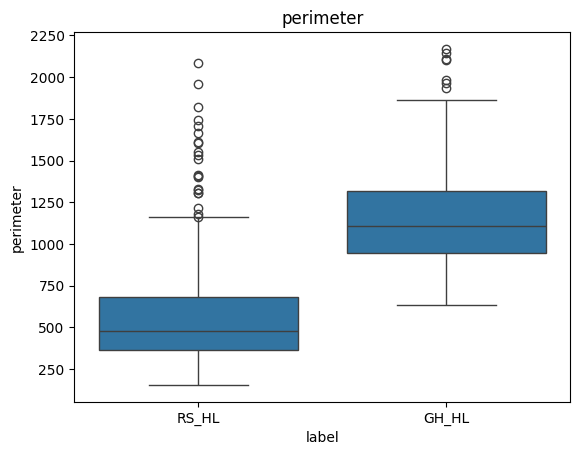

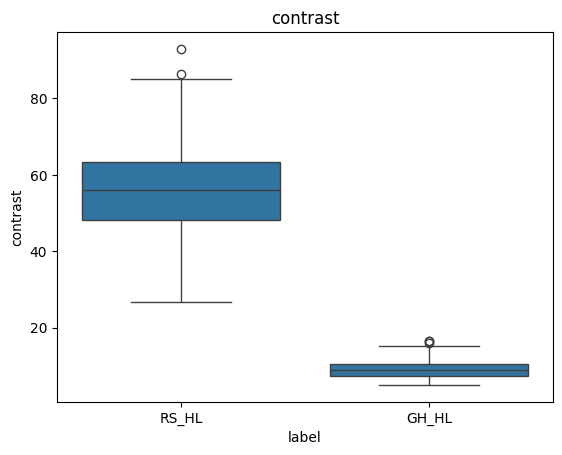

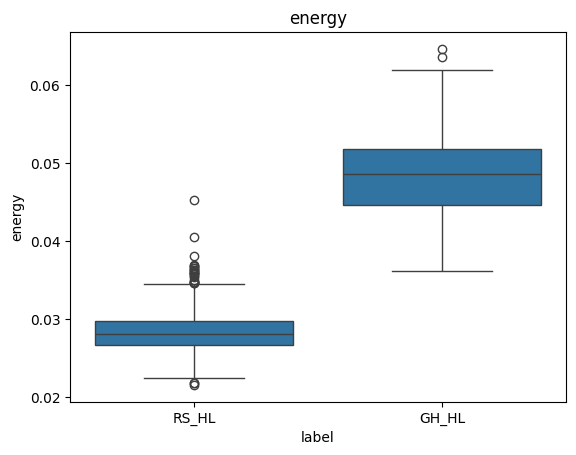

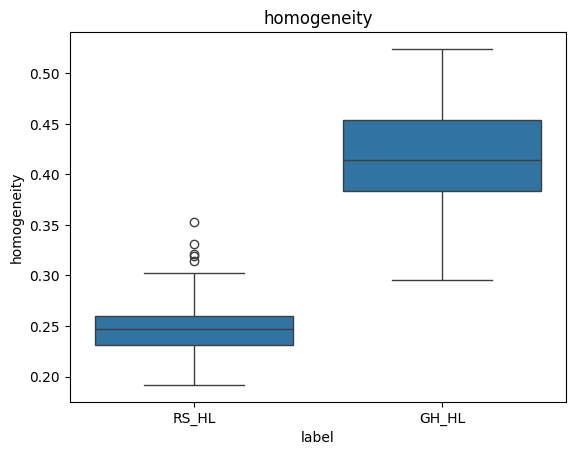

In [147]:
feature_list = [
    "mean_R", "mean_G", "mean_B",
    "area", "perimeter",
    "contrast", "energy", "homogeneity"
]

for col in feature_list:
    sns.boxplot(x="label", y=col, data=df)
    plt.title(f"{col}")
    plt.show()

# **12. Scatter Plot**

Melihat pemisahan antar kelas.


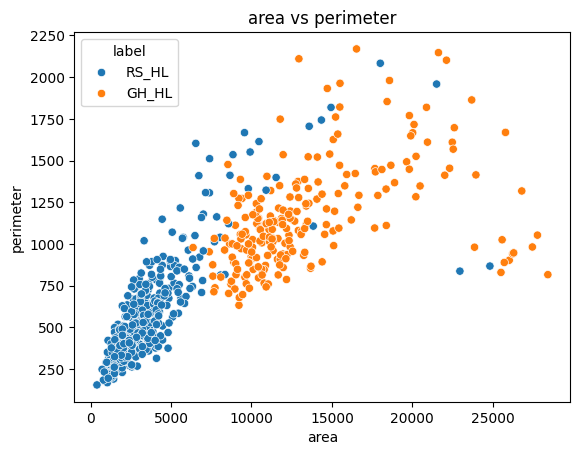

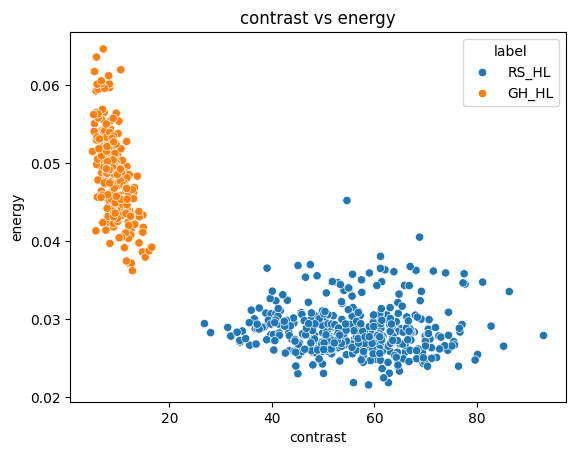

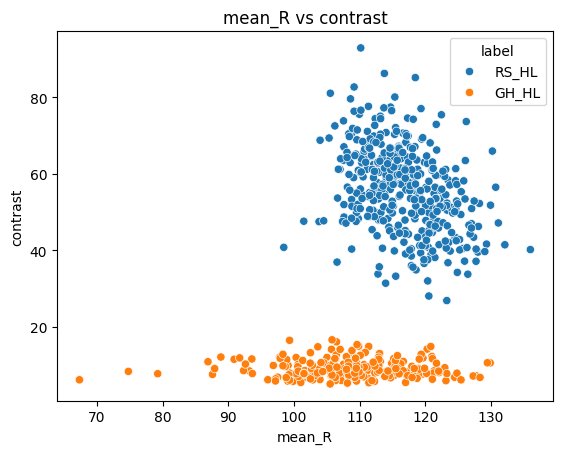

In [148]:
pairs = [
    ("area", "perimeter"),
    ("contrast", "energy"),
    ("mean_R", "contrast")
]

for x, y in pairs:
    sns.scatterplot(data=df, x=x, y=y, hue="label")
    plt.title(f"{x} vs {y}")
    plt.show()

# **13. Korelasi Fitur**
Mengetahui hubungan antar fitur.

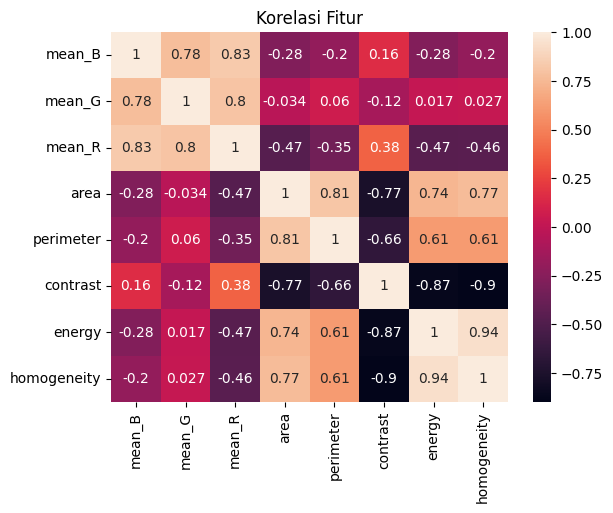

In [149]:
sns.heatmap(df.drop("label", axis=1).corr(), annot=True)
plt.title("Korelasi Fitur")
plt.show()

# **14. Confusion Matrix Visual**
Visualisasi confusion matrix dalam bentuk heatmap.

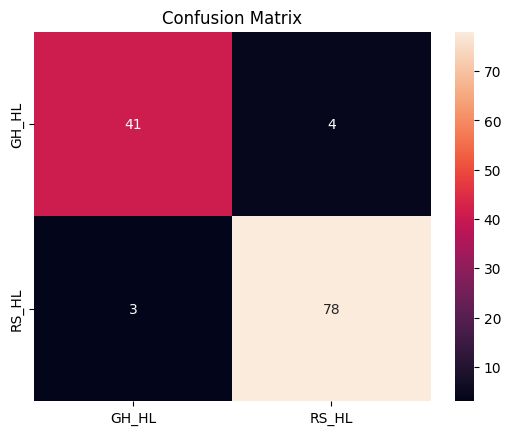

In [150]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.show()

# **15. Evaluasi Nilai K**
Mencari nilai K terbaik.

1 0.9441782178217822
3 0.9621584158415841
5 0.9641386138613861
7 0.9541980198019802
9 0.9541980198019802


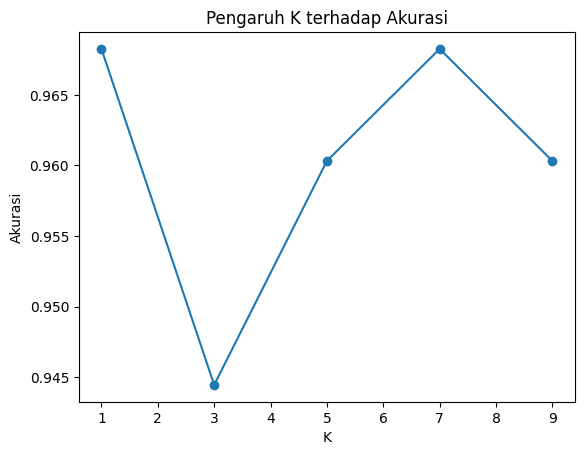

In [151]:
k_values = [1,3,5,7,9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracies.append(acc)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(k, scores.mean())

plt.plot(k_values, accuracies, marker='o')
plt.title("Pengaruh K terhadap Akurasi")
plt.xlabel("K")
plt.ylabel("Akurasi")
plt.show()

### **DOWNLOAD HASIL FITUR**

In [152]:
from google.colab import files

# Download CSV
files.download("/content/fitur_daun.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>